In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# --
list_params = ['outTempMax', 'outTempMin', 'avg_windSpeed', 'avg_windDir', 'total_rain', 'dateTime']

# --
'''df_mcp = pd.read_csv('data/data_meteo_mcp_2326.csv')[list_params]
df_mcp['dateTime'] = pd.to_datetime(df_mcp['dateTime'])'''
df_eda = pd.read_csv('data/data_meteo_eda_2326.csv')[list_params]
df_eda['dateTime'] = pd.to_datetime(df_eda['dateTime'])

# --
df_eda

,outTempMax,outTempMin,avg_windSpeed,avg_windDir,total_rain,dateTime
0,29.9,14.3,2,131.423907,5.8,2023-01-01 03:00:00+00:00
1,30.6,10.2,2,168.660072,0.0,2023-01-02 03:00:00+00:00
2,29.9,11.7,1,153.128990,0.7,2023-01-03 03:00:00+00:00
3,31.4,13.5,2,150.192348,0.0,2023-01-04 03:00:00+00:00
4,33.5,12.2,2,190.833822,0.0,2023-01-05 03:00:00+00:00
...,...,...,...,...,...,...
930,31.0,16.0,1,133.647541,0.0,2025-12-28 03:00:00+00:00
931,31.0,18.0,1,141.336207,0.0,2025-12-29 03:00:00+00:00
932,34.0,17.0,2,191.664122,0.0,2025-12-30 03:00:00+00:00
933,36.0,19.0,1,140.186047,0.0,2025-12-31 03:00:00+00:00


In [ ]:
def rem_outl_std(x, times=2):
    x_median = np.nanmedian(x)
    x_std = np.nanstd(x)
    
    return np.where(((x < x_median-times*x_std) | (x > x_median+times*x_std)), np.nan, x)

def nanmedian_two(array_1, array_2):
    """Median of two arrays combined, ignoring NaNs.

    The arrays can have different shapes; both are flattened and joined.
    Returns NaN if every value is NaN.
    """
    stack = np.stack([array_1, array_2], axis=0)
    #print(stack.shape)
    return np.nanmedian(stack, axis=0)

def idw_two_stations(data_1, data_2, xy_point, xy_1, xy_2, power=1):
    """
    https://en.wikipedia.org/wiki/Inverse_distance_weighting
    Distance-weighted mean of two station series at a target point.

    data_1, data_2 : arrays of the same shape (e.g. time series), NaNs allowed
    xy_point, xy_1, xy_2 : (easting, northing) in UTM meters
    power : IDW exponent (1 = inverse distance, 2 = inverse distance squared)
    """

    if data_1.shape != data_2.shape:
        raise ValueError(f"Shape mismatch: {data_1.shape} vs {data_2.shape}")

    d1 = np.hypot(xy_point[0] - xy_1[0], xy_point[1] - xy_1[1])
    d2 = np.hypot(xy_point[0] - xy_2[0], xy_point[1] - xy_2[1])

    # Point coincides with a station: use that station directly
    if d1 == 0:
        return np.where(np.isnan(data_1), data_2, data_1)
    if d2 == 0:
        return np.where(np.isnan(data_2), data_1, data_2)

    w1 = 1.0 / d1**power
    w2 = 1.0 / d2**power

    # Zero out weights where data is NaN, then renormalize per element
    W1 = np.where(np.isnan(data_1), 0.0, w1)
    W2 = np.where(np.isnan(data_2), 0.0, w2)
    num = W1 * np.nan_to_num(data_1) + W2 * np.nan_to_num(data_2) # nan_to_num converts nan to 0
    den = W1 + W2

    return np.where(den > 0, num / den, np.nan)

In [13]:
# --
'''medn_mcp = nanmedian_two(rem_outl_std(np.array(df_mcp['outTempMax'])), 
              rem_outl_std(np.array(df_mcp['outTempMin'])))'''

medn_eda = nanmedian_two(rem_outl_std(np.array(df_eda['outTempMax'])), 
              rem_outl_std(np.array(df_eda['outTempMin'])))

/tmp/ipykernel_32478/2535489107.py:15: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(stack, axis=0)


/tmp/ipykernel_32478/2349027305.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='best')
/tmp/ipykernel_32478/2349027305.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(loc='best')
/tmp/ipykernel_32478/2349027305.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3].legend(loc='best')


Text(0.5, 1.0, 'E. D. Alighieri-PP Acumulada')

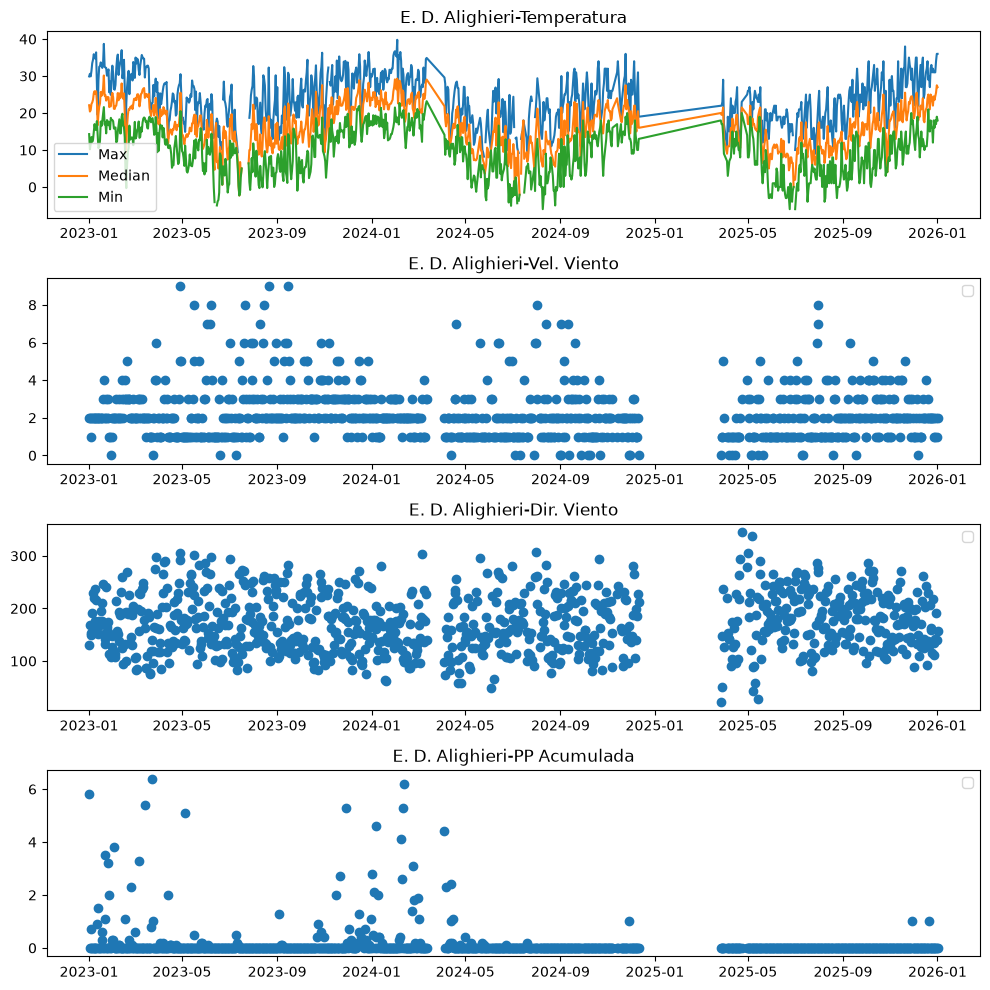

In [31]:
#fig, ax = plt.subplots(2, 1, figsize=(10, 8))
fig, ax = plt.subplots(4, 1, figsize=(10, 10), tight_layout=True)

# --
'''ax[0].plot(df_mcp['dateTime'], rem_outl_std(np.array(df_mcp['outTempMax'])), label='Max')
ax[0].plot(df_mcp['dateTime'], medn_mcp, label='Median')
ax[0].plot(df_mcp['dateTime'], rem_outl_std(np.array(df_mcp['outTempMin'])), label='Min')

ax[0].legend(loc='best')
ax[0].set_title('M. C. Paz')'''

# --
ax[0].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['outTempMax'])), label='Max')
ax[0].plot(df_eda['dateTime'], medn_eda, label='Median')
ax[0].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['outTempMin'])), label='Min')

ax[0].legend(loc='best')
ax[0].set_title('E. D. Alighieri-Temperatura')

# --
ax[1].plot(df_eda['dateTime'], df_eda['avg_windSpeed'], marker='o', linestyle='none', label='')

ax[1].legend(loc='best')
ax[1].set_title('E. D. Alighieri-Vel. Viento')

# --
ax[2].plot(df_eda['dateTime'], df_eda['avg_windDir'], marker='o', linestyle='none', label='')

ax[2].legend(loc='best')
ax[2].set_title('E. D. Alighieri-Dir. Viento')

# --
ax[3].plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['total_rain'])), marker='o', linestyle='none', label='')

ax[3].legend(loc='best')
ax[3].set_title('E. D. Alighieri-PP Acumulada')

# ['outTempMax', 'outTempMin', 'avg_windSpeed', 'avg_windDir', 'total_rain', 'dateTime']
